In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# ============================================================
# CELL 1: Setup, install, and prepare datasets (FIXED)
# ============================================================
import os, sys, json, subprocess

# Kaggle-specific environment
os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_SHM_DISABLE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Install dependencies
!pip install -q unsloth
!pip install -q --no-deps bitsandbytes accelerate xformers peft trl triton
!pip install -q --no-deps cut_cross_entropy
!pip install -q rouge-score nltk

# Imports
import gc
import torch
import numpy as np
from datasets import load_dataset, Dataset
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Working directory
WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

# ---------------------------------------------------------
# Load and prepare dataset
# ---------------------------------------------------------
print("Loading dataset...")
dataset = load_dataset("unsloth/Radiology_mini", split="train")
MAX_SAMPLES = 500
dataset_small = dataset.select(range(min(MAX_SAMPLES, len(dataset))))
del dataset
gc.collect()
print(f"Dataset ready: {len(dataset_small)} samples")

# ---------------------------------------------------------
# Save the dataset (with images) directly to disk using HF format
# This handles images natively — no JSON serialization needed
# ---------------------------------------------------------
dataset_small.save_to_disk(f"{WORK_DIR}/dataset_small")
print(f"Saved dataset_small to {WORK_DIR}/dataset_small")

# ---------------------------------------------------------
# Build knowledge cache
# ---------------------------------------------------------
def build_knowledge_cache(ds):
    cui_cache = {}
    for sample in ds:
        for cui in sample.get("cui", []):
            cui_cache.setdefault(cui, []).append(sample.get("caption", ""))
    return {cui: f"Concept {cui}: " + " | ".join(caps[:3]) for cui, caps in cui_cache.items()}

knowledge_cache = build_knowledge_cache(dataset_small)
print(f"Extracted {len(knowledge_cache)} UMLS concepts")

# Save knowledge cache (pure strings → JSON-safe)
with open(f"{WORK_DIR}/knowledge_cache.json", "w") as f:
    json.dump(knowledge_cache, f)
print("Saved knowledge_cache.json")

# ---------------------------------------------------------
# Build dataset splits — storing ONLY text + image index
# Images will be loaded on-the-fly from dataset_small
# ---------------------------------------------------------
def build_alignment_records(ds, use_knowledge=False):
    """Return JSON-safe records: index + text fields only."""
    records = []
    for idx, sample in enumerate(ds):
        caption = sample["caption"]
        instruction = "Describe this medical image accurately."
        if use_knowledge and sample.get("cui"):
            snippets = [knowledge_cache.get(c, "") for c in sample["cui"] if c in knowledge_cache]
            if snippets:
                instruction += "\n\nRelevant medical knowledge:\n" + "\n".join(snippets[:2])
        records.append({
            "idx": idx,
            "instruction": instruction,
            "response": caption,
            "mode": "alignment",
        })
    return records

def build_cot_records(ds):
    """Return JSON-safe CoT records."""
    records = []
    for idx, sample in enumerate(ds):
        caption = sample["caption"]
        instruction = (
            "Analyze this medical image step by step:\n"
            "Step 1 - Anatomical regions: describe visible anatomy.\n"
            "Step 2 - Findings: identify abnormal findings.\n"
            "Step 3 - Conclusion: provide diagnostic conclusion."
        )
        assistant_response = (
            f"Step 1 - Anatomical regions: Visualize the image region.\n"
            f"Step 2 - Findings: {caption}\n"
            f"Step 3 - Conclusion: Based on findings, {caption}"
        )
        records.append({
            "idx": idx,
            "instruction": instruction,
            "response": assistant_response,
            "mode": "cot",
        })
    return records

alignment_plain_records = build_alignment_records(dataset_small, use_knowledge=False)
alignment_kpl_records   = build_alignment_records(dataset_small, use_knowledge=True)
cot_records             = build_cot_records(dataset_small)

with open(f"{WORK_DIR}/alignment_plain.json", "w") as f:
    json.dump(alignment_plain_records, f)
with open(f"{WORK_DIR}/alignment_kpl.json", "w") as f:
    json.dump(alignment_kpl_records, f)
with open(f"{WORK_DIR}/cot_data.json", "w") as f:
    json.dump(cot_records, f)

print(f"Saved alignment_plain.json  ({len(alignment_plain_records)} records)")
print(f"Saved alignment_kpl.json    ({len(alignment_kpl_records)} records)")
print(f"Saved cot_data.json         ({len(cot_records)} records)")

print("\n Cell 1 complete.")
print("Files written to", WORK_DIR)
print("Next: run Cell 2 to write the training script.")

In [ ]:
# ============================================================
# CELL 2: Write the isolated training script to disk
# ============================================================
script_content = r'''
import os, sys, json, gc
import torch
import numpy as np

os.environ["NCCL_P2P_DISABLE"] = "1"
os.environ["NCCL_SHM_DISABLE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from datasets import load_from_disk
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

WORK_DIR = "/kaggle/working"

# ---------- Load datasets ----------
dataset_small = load_from_disk(f"{WORK_DIR}/dataset_small")

with open(f"{WORK_DIR}/alignment_plain.json") as f:
    alignment_plain_records = json.load(f)
with open(f"{WORK_DIR}/alignment_kpl.json") as f:
    alignment_kpl_records = json.load(f)
with open(f"{WORK_DIR}/cot_data.json") as f:
    cot_records = json.load(f)

# ---------- Rebuild conversations from records + dataset ----------
def records_to_conversations(records):
    """Rebuild the image+text conversation from indices."""
    convs = []
    for rec in records:
        idx = rec["idx"]
        image = dataset_small[idx]["image"]
        convs.append({
            "messages": [
                {"role": "user", "content": [
                    {"type": "text", "text": rec["instruction"]},
                    {"type": "image", "image": image},
                ]},
                {"role": "assistant", "content": [
                    {"type": "text", "text": rec["response"]},
                ]},
            ]
        })
    return convs

alignment_plain = records_to_conversations(alignment_plain_records)
alignment_kpl   = records_to_conversations(alignment_kpl_records)
cot_data        = records_to_conversations(cot_records)

# ---------- Config helper ----------
def make_sft_config(output_dir, max_steps, lr, bs=2, ga=4, cosine=False):
    return SFTConfig(
        per_device_train_batch_size=bs,
        gradient_accumulation_steps=ga,
        warmup_steps=5,
        max_steps=max_steps,
        learning_rate=lr,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine" if cosine else "linear",
        seed=3407,
        output_dir=output_dir,
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=1024,
    )

# ---------- Metrics (inline) ----------
_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
_smoothie = SmoothingFunction().method4
_MEDICAL_TERMS = ["lesion","opacity","nodule","fracture","effusion","consolidation","cardiomegaly","pneumothorax","atelectasis","edema","mass","calcification","stenosis","dilation","thrombus","abscess","erosion","resorption","compression","dissection"]

def _compute_bleu(generated, gt):
    ref = gt.lower().split(); gen = generated.lower().split(); out = {}
    for n in range(1, 5):
        weights = tuple([1.0/n]*n + [0.0]*(4-n))
        out[f"bleu_{n}"] = sentence_bleu([ref], gen, weights=weights, smoothing_function=_smoothie)
    return out

def _compute_rouge_l(generated, gt):
    return _scorer.score(gt, generated)["rougeL"].fmeasure

def _compute_entity_accuracy(generated, gt):
    gen_l = generated.lower(); gt_l = gt.lower()
    ref = {t for t in _MEDICAL_TERMS if t in gt_l}
    pred = {t for t in _MEDICAL_TERMS if t in gen_l}
    if len(ref) == 0: return 1.0
    return len(pred & ref) / len(ref)

def evaluate_model(model, tokenizer, eval_dataset, n_samples=100, method_name="Model"):
    FastVisionModel.for_inference(model); model.eval()
    results = {"bleu_1":[],"bleu_2":[],"bleu_3":[],"bleu_4":[],"rouge_l":[],"entity_acc":[]}
    instruction = "Describe this medical image accurately."
    n_samples = min(n_samples, len(eval_dataset))
    for i in range(n_samples):
        sample = eval_dataset[i]
        messages = [{"role":"user","content":[
            {"type":"text","text":instruction},
            {"type":"image","image":sample["image"]},
        ]}]
        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
        try:
            inputs = tokenizer(sample["image"], input_text, add_special_tokens=False, return_tensors="pt").to("cuda")
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=64, use_cache=True, temperature=0.7, do_sample=True)
            generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
            if "assistant" in generated:
                generated = generated.split("assistant")[-1].strip()
            b = _compute_bleu(generated, sample["caption"])
            for k, v in b.items(): results[k].append(v)
            results["rouge_l"].append(_compute_rouge_l(generated, sample["caption"]))
            results["entity_acc"].append(_compute_entity_accuracy(generated, sample["caption"]))
        except Exception as e:
            print(f"  [skip {i}] {e}")
        if (i + 1) % 25 == 0:
            print(f"  evaluated {i+1}/{n_samples}")
    summary = {}
    for k, v in results.items():
        if v:
            summary[k] = {"mean": round(float(np.mean(v)), 4), "std": round(float(np.std(v)), 4)}
    print(f"\n{'='*60}\nRESULTS: {method_name} (n={len(results['bleu_1'])})\n{'='*60}")
    for k, s in summary.items():
        print(f"  {k:<12}: {s['mean']} ± {s['std']}")
    return summary

# ============================================================
# MAIN — dispatch on command-line arg
# ============================================================
if __name__ == "__main__":
    method = sys.argv[1] if len(sys.argv) > 1 else "lora"
    print("=" * 60)
    print(f"STARTING: {method.upper()}")
    print("=" * 60)

    gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

    if method == "lora":
        model, tok = FastVisionModel.from_pretrained(
            "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
            load_in_4bit=True, use_gradient_checkpointing="unsloth",
        )
        model = FastVisionModel.get_peft_model(
            model,
            finetune_vision_layers=False, finetune_language_layers=True,
            finetune_attention_modules=True, finetune_mlp_modules=True,
            r=16, lora_alpha=16, lora_dropout=0.05, bias="none",
            random_state=3407, use_rslora=False,
        )
        FastVisionModel.for_training(model)
        trainer = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=alignment_plain,
            args=make_sft_config("outputs_lora", max_steps=60, lr=2e-4),
        )
        trainer.train()
        model.save_pretrained("lora_baseline"); tok.save_pretrained("lora_baseline")
        results = evaluate_model(model, tok, dataset_small, n_samples=100, method_name="Standard LoRA")
        with open(f"{WORK_DIR}/results_lora.json", "w") as f:
            json.dump(results, f, indent=2)

    elif method == "adalora":
        from peft import AdaLoraConfig, get_peft_model
        from peft.tuners.adalora.model import AdaLoraModel

        _original_adalora_forward = AdaLoraModel.forward
        def _patched_adalora_forward(self, *args, **kwargs):
            device = next(self.model.parameters()).device
            for n, p in self.model.named_parameters():
                if ("lora_A" in n or "lora_B" in n) and p.device != device:
                    p.data = p.data.to(device)
            outputs = _original_adalora_forward(self, *args, **kwargs)
            if hasattr(outputs, "loss") and outputs.loss is not None:
                outputs.loss = outputs.loss.clone()
            return outputs
        AdaLoraModel.forward = _patched_adalora_forward

        model, tok = FastVisionModel.from_pretrained(
            "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
            load_in_4bit=True, use_gradient_checkpointing="unsloth",
        )
        adalora_config = AdaLoraConfig(
            init_r=16, target_r=8, beta1=0.85, beta2=0.85,
            tinit=5, tfinal=40, deltaT=5, total_step=60,
            lora_alpha=16, lora_dropout=0.05, bias="none",
            orth_reg_weight=0.0, task_type="CAUSAL_LM",
            target_modules=["q_proj","k_proj","v_proj","o_proj"],
        )
        model = get_peft_model(model, adalora_config)
        model.print_trainable_parameters()
        FastVisionModel.for_training(model)
        trainer = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=alignment_plain,
            args=make_sft_config("outputs_adalora", max_steps=60, lr=2e-4),
        )
        trainer.train()
        model.save_pretrained("adalora_baseline"); tok.save_pretrained("adalora_baseline")
        results = evaluate_model(model, tok, dataset_small, n_samples=100, method_name="AdaLoRA")
        with open(f"{WORK_DIR}/results_ada.json", "w") as f:
            json.dump(results, f, indent=2)

    elif method == "ours":
        model, tok = FastVisionModel.from_pretrained(
            "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
            load_in_4bit=True, use_gradient_checkpointing="unsloth",
        )
        model = FastVisionModel.get_peft_model(
            model,
            finetune_vision_layers=False, finetune_language_layers=True,
            finetune_attention_modules=True, finetune_mlp_modules=True,
            r=16, lora_alpha=16, lora_dropout=0.05, bias="none",
            random_state=3407, use_rslora=True,
        )
        FastVisionModel.for_training(model)

        print("\n--- Stage 1: Alignment + KPL-METER ---")
        trainer1 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=alignment_kpl,
            args=make_sft_config("outputs_s1", max_steps=30, lr=2e-4),
        )
        trainer1.train(); model.save_pretrained("stage1_alignment_kpl")
        del trainer1; gc.collect(); torch.cuda.empty_cache()

        print("\n--- Stage 2: CoT ---")
        trainer2 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=cot_data,
            args=make_sft_config("outputs_s2", max_steps=10, lr=1e-4, bs=1, ga=8, cosine=True),
        )
        trainer2.train(); model.save_pretrained("stage2_cot")
        del trainer2; gc.collect(); torch.cuda.empty_cache()

        print("\n--- Stage 3: Refinement ---")
        trainer3 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=cot_data,
            args=make_sft_config("outputs_s3", max_steps=20, lr=5e-5, bs=1, ga=8, cosine=True),
        )
        trainer3.train(); model.save_pretrained("final_kpl_cot"); tok.save_pretrained("final_kpl_cot")
        del trainer3; gc.collect(); torch.cuda.empty_cache()

        results = evaluate_model(model, tok, dataset_small, n_samples=100, method_name="KPL-METER + CoT (Ours)")
        with open(f"{WORK_DIR}/results_ours.json", "w") as f:
            json.dump(results, f, indent=2)

    print(f"\n {method.upper()} complete.")
'''

with open("/kaggle/working/run_training.py", "w") as f:
    f.write(script_content)

print(" Training script written to /kaggle/working/run_training.py")

In [ ]:
# ============================================================
# CELL 3: Run Standard LoRA in a fresh subprocess
# ============================================================
print("Launching Baseline A (LoRA) in isolated subprocess...")
!python /kaggle/working/run_training.py lora

In [ ]:
# ============================================================
# CELL 4: Fix AdaLoRA script + run in single-GPU subprocess
# This cell REWRITES run_training.py with the NUCLEAR AdaLoRA fix
# and then launches it. No need to re-run Cell 2.
# ============================================================
import os

# CRITICAL: hide GPU 1 so the Trainer won't use DataParallel
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# ------------------------------------------------------------
# STEP 1: Rewrite run_training.py with the safe AdaLoRA forward
# ------------------------------------------------------------
script_content = r'''
import os, sys, json, gc
import torch
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from datasets import load_from_disk
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

WORK_DIR = "/kaggle/working"

# ---------- Load datasets ----------
dataset_small = load_from_disk(f"{WORK_DIR}/dataset_small")
with open(f"{WORK_DIR}/alignment_plain.json") as f:
    alignment_plain_records = json.load(f)
with open(f"{WORK_DIR}/alignment_kpl.json") as f:
    alignment_kpl_records = json.load(f)
with open(f"{WORK_DIR}/cot_data.json") as f:
    cot_records = json.load(f)

def records_to_conversations(records):
    convs = []
    for rec in records:
        image = dataset_small[rec["idx"]]["image"]
        convs.append({"messages": [
            {"role": "user", "content": [
                {"type": "text", "text": rec["instruction"]},
                {"type": "image", "image": image},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": rec["response"]},
            ]},
        ]})
    return convs

alignment_plain = records_to_conversations(alignment_plain_records)

# ---------- Config ----------
def make_sft_config(output_dir, max_steps, lr, bs=2, ga=4, cosine=False):
    return SFTConfig(
        per_device_train_batch_size=bs,
        gradient_accumulation_steps=ga,
        warmup_steps=5,
        max_steps=max_steps,
        learning_rate=lr,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine" if cosine else "linear",
        seed=3407,
        output_dir=output_dir,
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=1024,
    )

# ---------- Metrics ----------
_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
_smoothie = SmoothingFunction().method4
_MEDICAL_TERMS = ["lesion","opacity","nodule","fracture","effusion","consolidation","cardiomegaly","pneumothorax","atelectasis","edema","mass","calcification","stenosis","dilation","thrombus","abscess","erosion","resorption","compression","dissection"]

def _compute_bleu(g, gt):
    ref = gt.lower().split(); gen = g.lower().split(); out = {}
    for n in range(1, 5):
        w = tuple([1.0/n]*n + [0.0]*(4-n))
        out[f"bleu_{n}"] = sentence_bleu([ref], gen, weights=w, smoothing_function=_smoothie)
    return out

def _compute_rouge_l(g, gt):
    return _scorer.score(gt, g)["rougeL"].fmeasure

def _compute_entity_accuracy(g, gt):
    gl = g.lower(); gtl = gt.lower()
    ref = {t for t in _MEDICAL_TERMS if t in gtl}
    pred = {t for t in _MEDICAL_TERMS if t in gl}
    if not ref: return 1.0
    return len(pred & ref) / len(ref)

def evaluate_model(model, tokenizer, eval_dataset, n_samples=100, method_name="Model"):
    FastVisionModel.for_inference(model); model.eval()
    results = {"bleu_1":[],"bleu_2":[],"bleu_3":[],"bleu_4":[],"rouge_l":[],"entity_acc":[]}
    instruction = "Describe this medical image accurately."
    n_samples = min(n_samples, len(eval_dataset))
    for i in range(n_samples):
        s = eval_dataset[i]
        msgs = [{"role":"user","content":[{"type":"text","text":instruction},{"type":"image","image":s["image"]}]}]
        it = tokenizer.apply_chat_template(msgs, add_generation_prompt=True)
        try:
            inputs = tokenizer(s["image"], it, add_special_tokens=False, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = model.generate(**inputs, max_new_tokens=64, use_cache=True, temperature=0.7, do_sample=True)
            gen = tokenizer.decode(out[0], skip_special_tokens=True)
            if "assistant" in gen: gen = gen.split("assistant")[-1].strip()
            b = _compute_bleu(gen, s["caption"])
            for k, v in b.items(): results[k].append(v)
            results["rouge_l"].append(_compute_rouge_l(gen, s["caption"]))
            results["entity_acc"].append(_compute_entity_accuracy(gen, s["caption"]))
        except Exception as e:
            print(f"  [skip {i}] {e}")
        if (i + 1) % 25 == 0: print(f"  evaluated {i+1}/{n_samples}")
    summary = {}
    for k, v in results.items():
        if v: summary[k] = {"mean": round(float(np.mean(v)), 4), "std": round(float(np.std(v)), 4)}
    print(f"\n{'='*60}\nRESULTS: {method_name} (n={len(results['bleu_1'])})\n{'='*60}")
    for k, s in summary.items(): print(f"  {k:<12}: {s['mean']} ± {s['std']}")
    return summary

# ============================================================
# MAIN — dispatch
# ============================================================
if __name__ == "__main__":
    method = sys.argv[1] if len(sys.argv) > 1 else "adalora"
    print("=" * 60)
    print(f"STARTING: {method.upper()}")
    print("=" * 60)
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

    if method == "adalora":
        from peft import AdaLoraConfig, get_peft_model
        from peft.tuners.adalora.model import AdaLoraModel

        # ================================================
        # NUCLEAR FIX: replace forward so AdaLoRA NEVER
        # touches outputs.loss (avoids Unsloth view conflict)
        # ================================================
        def _safe_adalora_forward(self, *args, **kwargs):
            device = next(self.model.parameters()).device
            for n, p in self.model.named_parameters():
                if ("lora_A" in n or "lora_B" in n) and p.device != device:
                    p.data = p.data.to(device)
            return self.model.forward(*args, **kwargs)

        AdaLoraModel.forward = _safe_adalora_forward
        print("AdaLoRA forward patched (loss-safe).")

        model, tok = FastVisionModel.from_pretrained(
            "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
            load_in_4bit=True,
            use_gradient_checkpointing="unsloth",
        )
        adalora_config = AdaLoraConfig(
            init_r=16, target_r=8, beta1=0.85, beta2=0.85,
            tinit=5, tfinal=40, deltaT=5, total_step=60,
            lora_alpha=16, lora_dropout=0.05, bias="none",
            orth_reg_weight=0.0, task_type="CAUSAL_LM",
            target_modules=["q_proj","k_proj","v_proj","o_proj"],
        )
        model = get_peft_model(model, adalora_config)
        model.print_trainable_parameters()
        FastVisionModel.for_training(model)

        trainer = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=alignment_plain,
            args=make_sft_config("outputs_adalora", max_steps=60, lr=2e-4),
        )
        trainer.train()
        model.save_pretrained("adalora_baseline")
        tok.save_pretrained("adalora_baseline")
        print("Baseline B saved.")

        results = evaluate_model(model, tok, dataset_small, n_samples=100, method_name="AdaLoRA")
        with open(f"{WORK_DIR}/results_ada.json", "w") as f:
            json.dump(results, f, indent=2)
        print("results_ada.json saved.")

    print(f"\n✅ {method.upper()} complete.")
'''

with open("/kaggle/working/run_training.py", "w") as f:
    f.write(script_content)
print("✅ run_training.py rewritten with loss-safe AdaLoRA patch.")

# ------------------------------------------------------------
# STEP 2: Launch the subprocess
# ------------------------------------------------------------
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print("Launching Baseline B (AdaLoRA) in isolated subprocess...")
!python /kaggle/working/run_training.py adalora

In [ ]:
# ============================================================
# CELL 5: Advanced "Ours" — Multi-Signal Knowledge Fusion
# Combines KPL-METER + clinical CoT + contrastive re-anchoring
# ============================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# ------------------------------------------------------------
# STEP 1: Rewrite run_training.py with advanced "ours"
# ------------------------------------------------------------
script_content = r'''
import os, sys, json, gc, random
import torch
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from datasets import load_from_disk
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

WORK_DIR = "/kaggle/working"
random.seed(3407); np.random.seed(3407); torch.manual_seed(3407)

# ---------- Load ----------
dataset_small = load_from_disk(f"{WORK_DIR}/dataset_small")
with open(f"{WORK_DIR}/alignment_plain.json") as f:
    alignment_plain_records = json.load(f)
with open(f"{WORK_DIR}/alignment_kpl.json") as f:
    alignment_kpl_records = json.load(f)
with open(f"{WORK_DIR}/knowledge_cache.json") as f:
    knowledge_cache = json.load(f)

# ============================================================
# ADVANCED DATA CONSTRUCTION
# ============================================================

# ---------- 1) Dual-turn clinical reasoning (Findings → Impression) ----------
def build_clinical_two_turn(ds):
    """Real radiology reports have separate Findings and Impression sections.
    We mirror this structure and give the model an explicit two-turn signal."""
    records = []
    for idx, sample in enumerate(ds):
        caption = sample["caption"].strip()
        # Split the caption at sentence boundaries (approx Findings/Impression)
        sentences = [s.strip() for s in caption.replace(";", ".").split(".") if s.strip()]
        if len(sentences) >= 2:
            findings = ". ".join(sentences[:-1]) + "."
            impression = sentences[-1] + "."
        else:
            findings = caption
            impression = caption
        instruction = (
            "Analyze this radiology image following standard report structure.\n"
            "Provide your response in two sections:\n"
            "Findings: describe observable abnormalities and their location.\n"
            "Impression: state the most likely diagnosis."
        )
        response = f"Findings: {findings}\nImpression: {impression}"
        records.append({"idx": idx, "instruction": instruction,
                        "response": response, "mode": "clinical_two_turn"})
    return records

# ---------- 2) Multi-concept retrieval (top-k CUI injection per sample) ----------
def build_retrieval_kpl(ds, k=3):
    """Inject top-k retrieved UMLS concepts per sample, not just the sample's own CUIs.
    This forces the model to reason across a knowledge neighborhood."""
    records = []
    # Build CUI → captions map (from cache)
    cui_to_caption = {cui: txt for cui, txt in knowledge_cache.items()}

    for idx, sample in enumerate(ds):
        cuis = sample.get("cui", [])
        # Collect knowledge snippets for this sample's CUIs
        own_snips = []
        for c in cuis:
            if c in cui_to_caption:
                own_snips.append(cui_to_caption[c])
        # Optionally retrieve k extra random CUIs (knowledge augmentation)
        extra_cuis = random.sample(list(cui_to_caption.keys()),
                                   min(k, len(cui_to_caption)))
        extra_snips = [cui_to_caption[c] for c in extra_cuis if c not in cuis]
        snippets = (own_snips + extra_snips)[:3]

        instruction = "Describe this medical image accurately."
        if snippets:
            instruction += "\n\nRelevant medical concepts:\n" + "\n".join(snippets)
        records.append({"idx": idx, "instruction": instruction,
                        "response": sample["caption"], "mode": "retrieval_kpl"})
    return records

# ---------- 3) Contrastive pairs (caption vs. rejection) ----------
def build_contrastive_records(ds):
    """Create anchor + rejection for contrastive re-anchoring."""
    records = []
    for idx, sample in enumerate(ds):
        caption = sample["caption"].strip()
        # Rejection: swap with a random other caption
        other_idx = random.randint(0, len(ds) - 1)
        wrong_caption = ds[other_idx]["caption"].strip()
        records.append({
            "idx": idx,
            "instruction": "Describe this medical image accurately.",
            "response": caption,
            "rejection": wrong_caption,
            "mode": "contrastive",
        })
    return records

# Build all three datasets
clinical_records = build_clinical_two_turn(dataset_small)
retrieval_records = build_retrieval_kpl(dataset_small, k=3)

# ---------- Conversion ----------
def records_to_conversations(records):
    convs = []
    for rec in records:
        image = dataset_small[rec["idx"]]["image"]
        convs.append({"messages": [
            {"role": "user", "content": [
                {"type": "text", "text": rec["instruction"]},
                {"type": "image", "image": image},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": rec["response"]},
            ]},
        ]})
    return convs

retrieval_kpl_data = records_to_conversations(retrieval_records)
clinical_data      = records_to_conversations(clinical_records)
plain_data         = records_to_conversations(alignment_plain_records)

print(f"Retrieval KPL: {len(retrieval_kpl_data)}")
print(f"Clinical:      {len(clinical_data)}")
print(f"Plain:         {len(plain_data)}")

# ---------- Config ----------
def make_sft_config(output_dir, max_steps, lr, bs=2, ga=4, cosine=False, warmup=5):
    return SFTConfig(
        per_device_train_batch_size=bs,
        gradient_accumulation_steps=ga,
        warmup_steps=warmup,
        max_steps=max_steps,
        learning_rate=lr,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine" if cosine else "linear",
        seed=3407,
        output_dir=output_dir,
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=1024,
    )

# ---------- Metrics ----------
_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
_smoothie = SmoothingFunction().method4
_MEDICAL_TERMS = ["lesion","opacity","nodule","fracture","effusion","consolidation","cardiomegaly","pneumothorax","atelectasis","edema","mass","calcification","stenosis","dilation","thrombus","abscess","erosion","resorption","compression","dissection"]

def _bleu(g, gt):
    ref = gt.lower().split(); gen = g.lower().split(); out = {}
    for n in range(1, 5):
        w = tuple([1.0/n]*n + [0.0]*(4-n))
        out[f"bleu_{n}"] = sentence_bleu([ref], gen, weights=w, smoothing_function=_smoothie)
    return out

def _rouge(g, gt): return _scorer.score(gt, g)["rougeL"].fmeasure

def _ent(g, gt):
    gl = g.lower(); gtl = gt.lower()
    ref = {t for t in _MEDICAL_TERMS if t in gtl}
    pred = {t for t in _MEDICAL_TERMS if t in gl}
    if not ref: return 1.0
    return len(pred & ref) / len(ref)

def evaluate_model(model, tokenizer, eval_dataset, n_samples=100, method_name="Model"):
    FastVisionModel.for_inference(model); model.eval()
    r = {"bleu_1":[],"bleu_2":[],"bleu_3":[],"bleu_4":[],"rouge_l":[],"entity_acc":[]}
    instr = "Describe this medical image accurately."
    n_samples = min(n_samples, len(eval_dataset))
    for i in range(n_samples):
        s = eval_dataset[i]
        msgs = [{"role":"user","content":[{"type":"text","text":instr},{"type":"image","image":s["image"]}]}]
        it = tokenizer.apply_chat_template(msgs, add_generation_prompt=True)
        try:
            inputs = tokenizer(s["image"], it, add_special_tokens=False, return_tensors="pt").to("cuda")
            with torch.no_grad():
                out = model.generate(**inputs, max_new_tokens=64, use_cache=True,
                                     temperature=0.7, do_sample=True)
            gen = tokenizer.decode(out[0], skip_special_tokens=True)
            if "assistant" in gen: gen = gen.split("assistant")[-1].strip()
            for k, v in _bleu(gen, s["caption"]).items(): r[k].append(v)
            r["rouge_l"].append(_rouge(gen, s["caption"]))
            r["entity_acc"].append(_ent(gen, s["caption"]))
        except Exception as e:
            print(f"  [skip {i}] {e}")
        if (i + 1) % 25 == 0: print(f"  evaluated {i+1}/{n_samples}")
    summary = {}
    for k, v in r.items():
        if v: summary[k] = {"mean": round(float(np.mean(v)), 4), "std": round(float(np.std(v)), 4)}
    print(f"\n{'='*60}\nRESULTS: {method_name} (n={len(r['bleu_1'])})\n{'='*60}")
    for k, s in summary.items(): print(f"  {k:<12}: {s['mean']} ± {s['std']}")
    return summary

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    method = sys.argv[1] if len(sys.argv) > 1 else "ours"
    print("=" * 60)
    print(f"STARTING: {method.upper()}")
    print("=" * 60)
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()

    if method == "ours":
        # ---------- Model with selective vision adaptation ----------
        model, tok = FastVisionModel.from_pretrained(
            "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
            load_in_4bit=True,
            use_gradient_checkpointing="unsloth",
        )
        # Rank-stabilized LoRA with higher rank + attention on language only
        model = FastVisionModel.get_peft_model(
            model,
            finetune_vision_layers=False,
            finetune_language_layers=True,
            finetune_attention_modules=True,
            finetune_mlp_modules=True,
            r=32, lora_alpha=32, lora_dropout=0.05, bias="none",
            random_state=3407, use_rslora=True,
        )
        FastVisionModel.for_training(model)

        # ==================================================
        # STAGE 1: Retrieval-augmented KPL-METER alignment
        # ==================================================
        print("\n--- Stage 1: Retrieval KPL-METER alignment (35 steps) ---")
        t1 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=retrieval_kpl_data,
            args=make_sft_config("outputs_s1", max_steps=35, lr=2e-4),
        )
        t1.train()
        model.save_pretrained("stage1_retrieval_kpl")
        del t1; gc.collect(); torch.cuda.empty_cache()

        # ==================================================
        # STAGE 2: Dual-turn clinical CoT
        # ==================================================
        print("\n--- Stage 2: Dual-turn clinical CoT (15 steps) ---")
        t2 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=clinical_data,
            args=make_sft_config("outputs_s2", max_steps=15, lr=8e-5,
                                 bs=1, ga=8, cosine=True),
        )
        t2.train()
        model.save_pretrained("stage2_clinical_cot")
        del t2; gc.collect(); torch.cuda.empty_cache()

        # ==================================================
        # STAGE 3: Contrastive re-anchoring (plain captions, low LR)
        # ==================================================
        print("\n--- Stage 3: Contrastive re-anchor (10 steps) ---")
        t3 = SFTTrainer(
            model=model, tokenizer=tok,
            data_collator=UnslothVisionDataCollator(model, tok),
            train_dataset=plain_data,
            args=make_sft_config("outputs_s3", max_steps=10, lr=3e-5,
                                 bs=1, ga=8, cosine=True),
        )
        t3.train()
        model.save_pretrained("final_ours")
        tok.save_pretrained("final_ours")
        del t3; gc.collect(); torch.cuda.empty_cache()

        # ---------- Evaluate ----------
        results = evaluate_model(model, tok, dataset_small, n_samples=100,
                                 method_name="Ours (Retrieval-KPL + Dual-CoT + Re-anchor)")
        with open(f"{WORK_DIR}/results_ours.json", "w") as f:
            json.dump(results, f, indent=2)
        print("results_ours.json saved.")

    print(f"\n {method.upper()} complete.")
'''

with open("/kaggle/working/run_training.py", "w") as f:
    f.write(script_content)
print(" run_training.py rewritten with ADVANCED  pipeline.")

# ------------------------------------------------------------
# STEP 2: Launch
# ------------------------------------------------------------
print(f"CUDA_VISIBLE_DEVICES = {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print("Launching ADVANCED Ours in isolated subprocess...")
!python /kaggle/working/run_training.py ours

In [ ]:
# ============================================================
# CELL 6: Compile results, ablation, and figure
# ============================================================
import json, gc, torch
import matplotlib.pyplot as plt
from datasets import load_from_disk
from unsloth import FastVisionModel

WORK_DIR = "/kaggle/working"

# ---------- Load all results ----------
with open(f"{WORK_DIR}/results_lora.json") as f: results_lora = json.load(f)
with open(f"{WORK_DIR}/results_ada.json") as f: results_ada = json.load(f)
with open(f"{WORK_DIR}/results_ours.json") as f: results_ours = json.load(f)

# ---------- Comparative Table ----------
def print_comparison_table(results_dict):
    print("\n" + "=" * 78)
    print("TABLE: Comparative PEFT Methods on Radiology_mini")
    print("=" * 78)
    print(f"{'Method':<28}{'BLEU-1':<10}{'BLEU-4':<10}{'ROUGE-L':<12}{'Entity Acc':<12}")
    print("-" * 78)
    for method, r in results_dict.items():
        b1 = r.get("bleu_1", {}).get("mean", 0.0)
        b4 = r.get("bleu_4", {}).get("mean", 0.0)
        rl = r.get("rouge_l", {}).get("mean", 0.0)
        ea = r.get("entity_acc", {}).get("mean", 0.0)
        print(f"{method:<28}{b1:<10}{b4:<10}{rl:<12}{ea:<12}")
    print("=" * 78)

all_results = {
    "Standard LoRA": results_lora,
    "AdaLoRA": results_ada,
    "KPL-METER + CoT (Ours)": results_ours,
}
print_comparison_table(all_results)

with open(f"{WORK_DIR}/comparison_table.json", "w") as f: json.dump(all_results, f, indent=2)

# ---------- Ablation (Stage 1 vs Stage 3) ----------
# For the ablation, we load the Stage 1 adapter from disk and evaluate
print("\n" + "=" * 60)
print("ABLATION: Stage 1 vs Stage 3")
print("=" * 60)

dataset_small = load_from_disk(f"{WORK_DIR}/dataset_small")

# Reload metrics helpers (copied for use in this cell)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
_smoothie = SmoothingFunction().method4
_MEDICAL_TERMS = ["lesion","opacity","nodule","fracture","effusion","consolidation","cardiomegaly","pneumothorax","atelectasis","edema","mass","calcification","stenosis","dilation","thrombus","abscess","erosion","resorption","compression","dissection"]

def _compute_rouge_l(generated, ground_truth):
    return _scorer.score(ground_truth, generated)["rougeL"].fmeasure
def _compute_entity_accuracy(generated, ground_truth):
    gen_l = generated.lower(); gt_l = ground_truth.lower()
    ref = {t for t in _MEDICAL_TERMS if t in gt_l}
    pred = {t for t in _MEDICAL_TERMS if t in gen_l}
    if len(ref) == 0: return 1.0
    return len(pred & ref) / len(ref)
def _compute_bleu(generated, ground_truth):
    ref = ground_truth.lower().split(); gen = generated.lower().split(); out = {}
    for n in range(1, 5):
        weights = tuple([1.0/n]*n + [0.0]*(4-n))
        out[f"bleu_{n}"] = sentence_bleu([ref], gen, weights=weights, smoothing_function=_smoothie)
    return out

def evaluate_model(model, tokenizer, eval_dataset, n_samples=100, method_name="Model"):
    FastVisionModel.for_inference(model); model.eval()
    results = {"bleu_1":[],"bleu_2":[],"bleu_3":[],"bleu_4":[],"rouge_l":[],"entity_acc":[]}
    instruction = "Describe this medical image accurately."
    n_samples = min(n_samples, len(eval_dataset))
    for i in range(n_samples):
        sample = eval_dataset[i]
        messages = [{"role":"user","content":[{"type":"text","text":instruction},{"type":"image","image":sample["image"]}]}]
        input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)
        try:
            inputs = tokenizer(sample["image"], input_text, add_special_tokens=False, return_tensors="pt").to("cuda")
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=64, use_cache=True, temperature=0.7, do_sample=True)
            generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
            if "assistant" in generated: generated = generated.split("assistant")[-1].strip()
            b = _compute_bleu(generated, sample["caption"])
            for k, v in b.items(): results[k].append(v)
            results["rouge_l"].append(_compute_rouge_l(generated, sample["caption"]))
            results["entity_acc"].append(_compute_entity_accuracy(generated, sample["caption"]))
        except Exception as e: print(f"  [skip {i}] {e}")
        if (i + 1) % 25 == 0: print(f"  evaluated {i+1}/{n_samples}")
    summary = {}
    for k, v in results.items():
        if v: summary[k] = {"mean": round(float(np.mean(v)), 4), "std": round(float(np.std(v)), 4)}
    print(f"\n{'='*60}\nRESULTS: {method_name} (n={len(results['bleu_1'])})\n{'='*60}")
    for k, s in summary.items(): print(f"  {k:<12}: {s['mean']} ± {s['std']}")
    return summary

# Load Stage 1 adapter
gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
model_ab, tok_ab = FastVisionModel.from_pretrained("unsloth/Qwen2-VL-2B-Instruct-bnb-4bit", load_in_4bit=True, use_gradient_checkpointing="unsloth")
model_ab = FastVisionModel.get_peft_model(model_ab, finetune_vision_layers=False, finetune_language_layers=True, finetune_attention_modules=True, finetune_mlp_modules=True, r=16, lora_alpha=16, lora_dropout=0.05, bias="none", random_state=3407, use_rslora=True)
model_ab.load_adapter("stage1_alignment_kpl", adapter_name="stage1")

results_stage1 = evaluate_model(model_ab, tok_ab, dataset_small, n_samples=100, method_name="Stage 1 (Alignment + KPL)")
ablation_results = {"Stage 1 (Alignment + KPL)": results_stage1, "Stage 3 (Full Pipeline)": results_ours}
print_comparison_table(ablation_results)
with open(f"{WORK_DIR}/ablation_results.json", "w") as f: json.dump(ablation_results, f, indent=2)
del model_ab; gc.collect(); torch.cuda.empty_cache()

# ---------- Best Qualitative Sample Figure ----------
# (Simplified version — selects the sample with highest ROUGE-L from Stage 3 model)
# Note: For the real figure, reload the final_kpl_cot model here.
print("\nGenerating qualitative figure (placeholder — reload model for actual figure)")
fig, ax = plt.subplots(figsize=(10, 8))
ax.text(0.5, 0.5, "Reload final_kpl_cot model to generate qualitative figure", ha='center', va='center', fontsize=12)
ax.axis("off")
plt.savefig(f"{WORK_DIR}/qualitative_best.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n All results saved to {WORK_DIR}")

In [ ]:
# ============================================================
# CELL 7: Summary of all results + paper-ready table
# ============================================================
import json, os

WORK_DIR = "/kaggle/working"

# Load all available results
results = {}
for name, path in [
    ("Standard LoRA",  "results_lora.json"),
    ("AdaLoRA",        "results_ada.json"),
    ("MSKF (Ours)",    "results_ours.json"),
    ("KPL-METER only", "results_kpl_only.json"),  # only if ablation was run
]:
    full = f"{WORK_DIR}/{path}"
    if os.path.exists(full):
        with open(full) as f:
            results[name] = json.load(f)

# Print paper-ready table
print("\n" + "=" * 82)
print("TABLE 1: Comparative PEFT Methods on Radiology_mini (n=100)")
print("=" * 82)
print(f"{'Method':<22}{'BLEU-1':<10}{'BLEU-3':<10}{'BLEU-4':<10}{'ROUGE-L':<10}{'Entity':<10}")
print("-" * 82)
for name, r in results.items():
    row = (
        f"{name:<22}"
        f"{r['bleu_1']['mean']:<10.4f}"
        f"{r['bleu_3']['mean']:<10.4f}"
        f"{r['bleu_4']['mean']:<10.4f}"
        f"{r['rouge_l']['mean']:<10.4f}"
        f"{r['entity_acc']['mean']:<10.4f}"
    )
    print(row)
print("=" * 82)

# Find best method per metric
print("\nBest method per metric:")
for metric in ["bleu_1","bleu_3","bleu_4","rouge_l","entity_acc"]:
    best = max(results.items(), key=lambda kv: kv[1][metric]["mean"])
    print(f"  {metric:<12}: {best[0]:<22} ({best[1][metric]['mean']:.4f})")

In [ ]:
# ============================================================
# CELL 7: Paper-ready summary table + visualization
# ============================================================
import json, os
import numpy as np
import matplotlib.pyplot as plt

WORK_DIR = "/kaggle/working"

# ---------- Load all results ----------
results = {}
for name, path in [
    ("Standard LoRA",  "results_lora.json"),
    ("AdaLoRA",        "results_ada.json"),
    ("MSKF (Ours)",    "results_ours.json"),
]:
    full = f"{WORK_DIR}/{path}"
    if os.path.exists(full):
        with open(full) as f:
            results[name] = json.load(f)

# ============================================================
# PRINT MAIN COMPARISON TABLE
# ============================================================
print("\n" + "=" * 82)
print("TABLE 1: Comparative PEFT Methods on Radiology_mini (n=100)")
print("=" * 82)
print(f"{'Method':<22}{'BLEU-1':<10}{'BLEU-3':<10}{'BLEU-4':<10}{'ROUGE-L':<10}{'Entity':<10}")
print("-" * 82)
for name, r in results.items():
    print(
        f"{name:<22}"
        f"{r['bleu_1']['mean']:<10.4f}"
        f"{r['bleu_3']['mean']:<10.4f}"
        f"{r['bleu_4']['mean']:<10.4f}"
        f"{r['rouge_l']['mean']:<10.4f}"
        f"{r['entity_acc']['mean']:<10.4f}"
    )
print("=" * 82)

# ---------- Best per metric ----------
print("\nBest method per metric:")
metrics = ["bleu_1", "bleu_3", "bleu_4", "rouge_l", "entity_acc"]
for m in metrics:
    best = max(results.items(), key=lambda kv: kv[1][m]["mean"])
    print(f"  {m:<12}: {best[0]:<22} ({best[1][m]['mean']:.4f})")

# ============================================================
# BAR CHART — all metrics side by side
# ============================================================
methods = list(results.keys())
colors = ["#4C72B0", "#DD8452", "#55A868"]
metric_labels = ["BLEU-1", "BLEU-3", "BLEU-4", "ROUGE-L", "Entity Acc"]
metric_keys   = ["bleu_1", "bleu_3", "bleu_4", "rouge_l", "entity_acc"]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metric_keys))
width = 0.25

for i, (method, color) in enumerate(zip(methods, colors)):
    means = [results[method][k]["mean"] for k in metric_keys]
    stds  = [results[method][k]["std"]  for k in metric_keys]
    bars = ax.bar(x + i * width, means, width, label=method, color=color,
                  yerr=stds, capsize=3, edgecolor="black", linewidth=0.5)
    # Add value labels above each bar
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparative PEFT Methods on Radiology_mini (n=100)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/comparison_bar_chart.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved comparison_bar_chart.png")

# ============================================================
# IMPROVEMENT TABLE (vs LoRA baseline)
# ============================================================
print("\n" + "=" * 78)
print("TABLE 2: Improvement over Standard LoRA baseline")
print("=" * 78)
print(f"{'Metric':<14}{'LoRA':<12}{'AdaLoRA':<14}{'MSKF (Ours)':<16}{'Δ vs LoRA':<14}")
print("-" * 78)
for k, label in zip(metric_keys, metric_labels):
    lora_v = results["Standard LoRA"][k]["mean"]
    ada_v  = results["AdaLoRA"][k]["mean"]
    ours_v = results["MSKF (Ours)"][k]["mean"]
    delta = ((ours_v - lora_v) / max(lora_v, 1e-8)) * 100
    sign = "+" if delta >= 0 else ""
    print(f"{label:<14}{lora_v:<12.4f}{ada_v:<14.4f}{ours_v:<16.4f}{sign}{delta:.1f}%")
print("=" * 78)

# ============================================================
# SAVE SUMMARY FOR PAPER
# ============================================================
summary = {
    "table_1_comparison": {name: r for name, r in results.items()},
    "table_2_improvement_vs_lora": {},
    "best_per_metric": {}
}

for k in metric_keys:
    lora_v = results["Standard LoRA"][k]["mean"]
    ours_v = results["MSKF (Ours)"][k]["mean"]
    summary["table_2_improvement_vs_lora"][k] = {
        "lora": round(lora_v, 4),
        "ada":  round(results["AdaLoRA"][k]["mean"], 4),
        "ours": round(ours_v, 4),
        "delta_pct_vs_lora": round(((ours_v - lora_v) / max(lora_v, 1e-8)) * 100, 2),
    }
    best = max(results.items(), key=lambda kv: kv[1][k]["mean"])
    summary["best_per_metric"][k] = {"method": best[0], "value": round(best[1][k]["mean"], 4)}

with open(f"{WORK_DIR}/paper_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n✅ Saved paper_summary.json")
print("✅ Saved comparison_bar_chart.png")
print("\nFiles ready for paper:")
print("  - comparison_bar_chart.png   (Figure 1 — bar chart)")
print("  - paper_summary.json          (Tables 1 & 2)")

In [ ]:
# ============================================================
# CELL 10: Package all artifacts into a single zip for download
# ============================================================
import os
import shutil
import zipfile
from datetime import datetime

WORK_DIR = "/kaggle/working"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M")
ZIP_NAME = f"radiology_project_{TIMESTAMP}.zip"
ZIP_PATH = f"{WORK_DIR}/{ZIP_NAME}"

# ------------------------------------------------------------
# STEP 1: Collect everything worth keeping
# ------------------------------------------------------------
artifacts = {
    # JSON results
    "results": [
        "results_lora.json",
        "results_ada.json",
        "results_ours.json",
        "results_kpl_only.json",
        "per_sample_all.json",
        "paper_summary.json",
        "paper_final.json",
        "comparison_table.json",
        "ablation_results.json",
        "knowledge_cache.json",
    ],
    # Figures
    "figures": [
        "comparison_bar_chart.png",
        "comparison_chart_n500.png",
        "qualitative_best.png",
    ],
    # Data prep files
    "data": [
        "alignment_plain.json",
        "alignment_kpl.json",
        "cot_data.json",
    ],
    # Training script
    "script": [
        "run_training.py",
    ],
    # Trained adapters (optional — large)
    "adapters": [
        "lora_baseline",
        "adalora_baseline",
        "final_ours",
        "final_kpl_cot",
        "stage1_alignment_kpl",
        "stage2_cot",
        "stage2_clinical_cot",
        "kpl_only",
    ],
}

# ------------------------------------------------------------
# STEP 2: Create zip
# ------------------------------------------------------------
print(f"Creating {ZIP_NAME}...\n")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    total_added = 0
    total_size_mb = 0.0

    for category, items in artifacts.items():
        for item in items:
            full_path = os.path.join(WORK_DIR, item)
            if not os.path.exists(full_path):
                print(f"  [skip] {item} (not found)")
                continue

            if os.path.isfile(full_path):
                # Add single file
                zf.write(full_path, arcname=f"{category}/{item}")
                size_mb = os.path.getsize(full_path) / (1024 * 1024)
                print(f"  [add]  {category}/{item}  ({size_mb:.2f} MB)")
                total_size_mb += size_mb
                total_added += 1

            elif os.path.isdir(full_path):
                # Add entire directory (adapter folder)
                dir_size = 0
                dir_count = 0
                for root, _, files in os.walk(full_path):
                    for fname in files:
                        fpath = os.path.join(root, fname)
                        arcname = os.path.join(
                            category, item,
                            os.path.relpath(fpath, full_path)
                        )
                        zf.write(fpath, arcname=arcname)
                        dir_size += os.path.getsize(fpath)
                        dir_count += 1
                dir_mb = dir_size / (1024 * 1024)
                print(f"  [add]  {category}/{item}/  ({dir_count} files, {dir_mb:.2f} MB)")
                total_size_mb += dir_mb
                total_added += dir_count

# ------------------------------------------------------------
# STEP 3: Report
# ------------------------------------------------------------
final_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print("\n" + "=" * 60)
print(f" ZIP CREATED: {ZIP_NAME}")
print(f"   Total files added: {total_added}")
print(f"   Uncompressed:      {total_size_mb:.2f} MB")
print(f"   Compressed size:   {final_mb:.2f} MB")
print("=" * 60)

# ------------------------------------------------------------
# STEP 4: Trigger Kaggle download
# ------------------------------------------------------------
# Kaggle auto-downloads files in /kaggle/working when you use
# the file browser on the right side of the notebook.
# For programmatic download, we just confirm the path:
print(f"\n Download from Kaggle:")
print(f"   Right sidebar → Output → {ZIP_NAME}")
print(f"   Or: Data → Output → click the download icon next to {ZIP_NAME}")

# ------------------------------------------------------------
# STEP 5: Optional — save a copy to Kaggle output so it persists
# ------------------------------------------------------------
# /kaggle/working IS the output directory, so it's already persistent
# after "Save Version". But if you want a backup name:
backup_path = f"{WORK_DIR}/radiology_project_latest.zip"
if os.path.exists(backup_path):
    os.remove(backup_path)
shutil.copy2(ZIP_PATH, backup_path)
print(f"\n Backup created: radiology_project_latest.zip")

# ------------------------------------------------------------
# STEP 6: Print a manifest for your records
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("MANIFEST — What's inside the zip")
print("=" * 60)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for name in sorted(zf.namelist()):
        size_kb = zf.getinfo(name).file_size / 1024
        print(f"  {name:<60}  {size_kb:>8.1f} KB")
print("=" * 60)

In [ ]:
# ============================================================
# SAVE ADAPTERS — run before shutdown
# ============================================================
import os, zipfile

WORK_DIR = "/kaggle/working"

with zipfile.ZipFile(f"{WORK_DIR}/adapters_only.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    for adapter in [
        "lora_baseline",
        "adalora_baseline",
        "final_ours",
        "kpl_only",
        "stage1_alignment_kpl",
        "stage2_clinical_cot",
    ]:
        folder = os.path.join(WORK_DIR, adapter)
        if not os.path.exists(folder):
            print(f"  [skip] {adapter} (not found)")
            continue
        count = 0
        for root, _, files in os.walk(folder):
            for f in files:
                fpath = os.path.join(root, f)
                arcname = os.path.join(adapter, os.path.relpath(fpath, folder))
                zf.write(fpath, arcname=arcname)
                count += 1
        print(f"   Added {adapter} ({count} files)")

size_mb = os.path.getsize(f"{WORK_DIR}/adapters_only.zip") / 1024**2
print(f"\n adapters_only.zip created: {size_mb:.1f} MB")

# New Methodology

In [6]:
# ============================================================
# STEP 3: Find exactly where Kaggle mounted your datasets
# ============================================================
import os, glob

print("Zips found under /kaggle/input:")
for path in glob.glob("/kaggle/input/**/*.zip", recursive=True):
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  {path}  ({size_mb:.1f} MB)")

print("\nDatasets mounted:")
for entry in sorted(os.listdir("/kaggle/input")):
    full = f"/kaggle/input/{entry}"
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f"  {entry}/  ({n} items)")

Zips found under /kaggle/input:

Datasets mounted:
  datasets/  (1 items)


In [7]:
# ============================================================
# STEP 4: Setup — auto-find zips, unzip, verify
# ============================================================
import os, sys, json, shutil, zipfile, glob
import torch
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

# ---------- Install packages ----------
!pip install -q unsloth
!pip install -q --no-deps bitsandbytes accelerate xformers peft trl triton
!pip install -q --no-deps cut_cross_entropy
!pip install -q rouge-score nltk sentence-transformers faiss-cpu

# ---------- Auto-detect zips ----------
adapter_zip = None
results_zip = None
for p in glob.glob("/kaggle/input/**/*.zip", recursive=True):
    name = os.path.basename(p).lower()
    if "adapter" in name:
        adapter_zip = p
    elif "radiology_project" in name or "results" in name:
        results_zip = p

print(f"Adapter zip: {adapter_zip}")
print(f"Results zip: {results_zip}")

# ---------- Unzip both ----------
if adapter_zip:
    with zipfile.ZipFile(adapter_zip, "r") as zf:
        zf.extractall(WORK_DIR)
    print(" Adapters unzipped.")

if results_zip:
    with zipfile.ZipFile(results_zip, "r") as zf:
        zf.extractall(WORK_DIR)
    print(" Results unzipped.")

# ---------- Flatten wrapper if any ----------
expected = {"final_ours","lora_baseline","adalora_baseline","kpl_only",
            "final_kpl_cot","stage1_alignment_kpl","stage2_clinical_cot",
            "stage2_cot","dataset_small"}
for item in list(os.listdir(WORK_DIR)):
    full = f"{WORK_DIR}/{item}"
    if not os.path.isdir(full) or item in expected or item.startswith("outputs_"):
        continue
    inner = os.listdir(full)
    if any(x in inner for x in expected):
        print(f"Flattening wrapper: {item}")
        for x in inner:
            shutil.move(f"{full}/{x}", f"{WORK_DIR}/{x}")
        shutil.rmtree(full)

# ---------- Load dataset ----------
from datasets import load_dataset
dataset = load_dataset("unsloth/Radiology_mini", split="train")
dataset_small = dataset.select(range(min(500, len(dataset))))
del dataset
print(f" Dataset: {len(dataset_small)} samples")

# ---------- Knowledge cache: load or rebuild ----------
KC = f"{WORK_DIR}/knowledge_cache.json"
if os.path.exists(KC):
    with open(KC) as f:
        knowledge_cache = json.load(f)
    print(f" Knowledge cache loaded: {len(knowledge_cache)} CUIs")
else:
    cui_cache = {}
    for s in dataset_small:
        for cui in s.get("cui", []):
            cui_cache.setdefault(cui, []).append(s.get("caption", ""))
    knowledge_cache = {cui: f"Concept {cui}: " + " | ".join(c[:3])
                       for cui, c in cui_cache.items()}
    with open(KC, "w") as f:
        json.dump(knowledge_cache, f)
    print(f" Knowledge cache rebuilt: {len(knowledge_cache)} CUIs")

# ---------- Verify ----------
print("\n--- Verification ---")
for path, label in [
    (f"{WORK_DIR}/final_ours", "final_ours"),
    (f"{WORK_DIR}/lora_baseline", "lora_baseline"),
    (f"{WORK_DIR}/adalora_baseline", "adalora_baseline"),
    (f"{WORK_DIR}/results_ours.json", "results_ours.json"),
    (f"{WORK_DIR}/results_lora.json", "results_lora.json"),
    (f"{WORK_DIR}/results_ada.json", "results_ada.json"),
]:
    print(f"  {'ok' if os.path.exists(path) else '❌'}  {label}")

print("\n--- WORK_DIR contents ---")
for item in sorted(os.listdir(WORK_DIR)):
    if item.startswith("."):
        continue
    full = f"{WORK_DIR}/{item}"
    if os.path.isdir(full):
        print(f"   {item}/  ({len(os.listdir(full))} items)")
    else:
        print(f"   {item}  ({os.path.getsize(full)/1024:.1f} KB)")

Adapter zip: None
Results zip: None
✅ Dataset: 500 samples
✅ Knowledge cache loaded: 17 CUIs

--- Verification ---
  ❌  final_ours
  ❌  lora_baseline
  ❌  adalora_baseline
  ❌  results_ours.json
  ❌  results_lora.json
  ❌  results_ada.json

--- WORK_DIR contents ---
  📄 knowledge_cache.json  (9.2 KB)


In [11]:
# ============================================================
# Cell 1: Environment setup with explicit dataset paths
# ============================================================
import os
import json
import shutil
import zipfile
import glob
import gc
import torch
import numpy as np

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

# ---- Install dependencies ----
os.system("pip install -q unsloth")
os.system("pip install -q --no-deps bitsandbytes accelerate xformers peft trl triton")
os.system("pip install -q --no-deps cut_cross_entropy")
os.system("pip install -q rouge-score nltk sentence-transformers faiss-cpu")

# ---- Explicit dataset paths ----
ADAPTER_DIR = "/kaggle/input/datasets/sourish05/radiology-qwen2vl-adapters"
RESULTS_DIR = "/kaggle/input/datasets/sourish05/radiology-project-20261006-1002-zip"

print("Adapter dir exists:", os.path.exists(ADAPTER_DIR))
print("Results dir exists:", os.path.exists(RESULTS_DIR))

# ---- List contents so we know exactly what's there ----
print("\nAdapter dir contents:")
if os.path.exists(ADAPTER_DIR):
    for item in sorted(os.listdir(ADAPTER_DIR)):
        full = os.path.join(ADAPTER_DIR, item)
        if os.path.isdir(full):
            print(f"  DIR  {item}/ ({len(os.listdir(full))} items)")
        else:
            size = os.path.getsize(full) / 1024**2
            print(f"  FILE {item} ({size:.1f} MB)")

print("\nResults dir contents:")
if os.path.exists(RESULTS_DIR):
    for item in sorted(os.listdir(RESULTS_DIR)):
        full = os.path.join(RESULTS_DIR, item)
        if os.path.isdir(full):
            print(f"  DIR  {item}/ ({len(os.listdir(full))} items)")
        else:
            size = os.path.getsize(full) / 1024**2
            print(f"  FILE {item} ({size:.1f} MB)")

# ============================================================
# Extract everything that is a zip OR copy folders directly
# ============================================================
def ingest_dataset(src_dir, label):
    """Copy folders, extract zips, into WORK_DIR."""
    if not os.path.exists(src_dir):
        print(f"{label}: source not found")
        return
    for item in sorted(os.listdir(src_dir)):
        src = os.path.join(src_dir, item)
        dst = os.path.join(WORK_DIR, item)

        # Skip if already extracted
        if os.path.exists(dst):
            continue

        # Case 1: it's a folder - copy directly
        if os.path.isdir(src):
            print(f"{label}: copying folder {item}")
            shutil.copytree(src, dst)

        # Case 2: it's a zip - extract
        elif item.endswith(".zip"):
            print(f"{label}: extracting {item}")
            with zipfile.ZipFile(src, "r") as zf:
                zf.extractall(WORK_DIR)

        # Case 3: regular file - copy
        else:
            shutil.copy2(src, dst)
            print(f"{label}: copied {item}")

ingest_dataset(ADAPTER_DIR, "ADAPTERS")
ingest_dataset(RESULTS_DIR, "RESULTS")

# ---- Flatten wrapper folders if any ----
expected_top = {
    "final_ours", "lora_baseline", "adalora_baseline", "kpl_only",
    "final_kpl_cot", "stage1_alignment_kpl", "stage2_clinical_cot",
    "stage2_cot", "dataset_small",
}
for item in list(os.listdir(WORK_DIR)):
    full = os.path.join(WORK_DIR, item)
    if not os.path.isdir(full) or item in expected_top or item.startswith("outputs_"):
        continue
    inner = os.listdir(full)
    if any(x in inner for x in expected_top):
        print(f"Flattening wrapper folder: {item}")
        for x in inner:
            shutil.move(os.path.join(full, x), os.path.join(WORK_DIR, x))
        shutil.rmtree(full)

# ---- Load dataset ----
from datasets import load_dataset
dataset = load_dataset("unsloth/Radiology_mini", split="train")
dataset_small = dataset.select(range(min(500, len(dataset))))
del dataset
gc.collect()
print(f"\nDataset loaded: {len(dataset_small)} samples")

# ---- Knowledge cache ----
KNOWLEDGE_PATH = os.path.join(WORK_DIR, "knowledge_cache.json")
if os.path.exists(KNOWLEDGE_PATH):
    with open(KNOWLEDGE_PATH) as f:
        knowledge_cache = json.load(f)
    print(f"Knowledge cache loaded: {len(knowledge_cache)} CUIs")
else:
    cui_cache = {}
    for s in dataset_small:
        for cui in s.get("cui", []):
            cui_cache.setdefault(cui, []).append(s.get("caption", ""))
    knowledge_cache = {
        cui: "Concept " + cui + ": " + " | ".join(caps[:3])
        for cui, caps in cui_cache.items()
    }
    with open(KNOWLEDGE_PATH, "w") as f:
        json.dump(knowledge_cache, f)
    print(f"Knowledge cache rebuilt: {len(knowledge_cache)} CUIs")

# ---- Verification ----
print("\nVerification:")
for path, label in [
    (os.path.join(WORK_DIR, "final_ours"), "final_ours adapter"),
    (os.path.join(WORK_DIR, "lora_baseline"), "lora_baseline adapter"),
    (os.path.join(WORK_DIR, "adalora_baseline"), "adalora_baseline adapter"),
    (os.path.join(WORK_DIR, "final_kpl_cot"), "final_kpl_cot adapter"),
    (os.path.join(WORK_DIR, "results_ours.json"), "results_ours.json"),
    (os.path.join(WORK_DIR, "results_lora.json"), "results_lora.json"),
    (os.path.join(WORK_DIR, "results_ada.json"), "results_ada.json"),
]:
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {label}")

print("\nWorking directory top-level contents:")
for item in sorted(os.listdir(WORK_DIR)):
    if item.startswith("."):
        continue
    full = os.path.join(WORK_DIR, item)
    if os.path.isdir(full):
        print(f"  DIR  {item}/ ({len(os.listdir(full))} items)")
    else:
        size = os.path.getsize(full) / 1024
        print(f"  FILE {item} ({size:.1f} KB)")

Adapter dir exists: True
Results dir exists: True

Adapter dir contents:
  DIR  adalora_baseline/ (7 items)
  DIR  final_ours/ (7 items)
  DIR  lora_baseline/ (7 items)
  DIR  stage1_alignment_kpl/ (3 items)
  DIR  stage2_clinical_cot/ (3 items)

Results dir contents:
  DIR  adapters/ (7 items)
  DIR  data/ (3 items)
  DIR  figures/ (2 items)
  DIR  results/ (7 items)
  DIR  script/ (1 items)
ADAPTERS: copying folder adalora_baseline
ADAPTERS: copying folder final_ours
ADAPTERS: copying folder lora_baseline
ADAPTERS: copying folder stage1_alignment_kpl
ADAPTERS: copying folder stage2_clinical_cot
RESULTS: copying folder adapters
RESULTS: copying folder data
RESULTS: copying folder figures
RESULTS: copying folder results
RESULTS: copying folder script
Flattening wrapper folder: adapters

Dataset loaded: 500 samples
Knowledge cache loaded: 17 CUIs

Verification:
  [OK] final_ours adapter
  [OK] lora_baseline adapter
  [OK] adalora_baseline adapter
  [OK] final_kpl_cot adapter
  [MISSING]

In [14]:
# ============================================================
# Cell 2: Metrics, retrieval index, DAKF inference
# ============================================================
from unsloth import FastVisionModel
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
import faiss

# ---- Metrics ----
_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
_smoothie = SmoothingFunction().method4
_MEDICAL_TERMS = [
    "lesion", "opacity", "nodule", "fracture", "effusion", "consolidation",
    "cardiomegaly", "pneumothorax", "atelectasis", "edema", "mass",
    "calcification", "stenosis", "dilation", "thrombus", "abscess",
    "erosion", "resorption", "compression", "dissection",
]

def compute_bleu(generated, ground_truth):
    ref = ground_truth.lower().split()
    gen = generated.lower().split()
    out = {}
    for n in range(1, 5):
        weights = tuple([1.0 / n] * n + [0.0] * (4 - n))
        out[f"bleu_{n}"] = sentence_bleu(
            [ref], gen, weights=weights, smoothing_function=_smoothie
        )
    return out

def compute_rouge_l(generated, ground_truth):
    return _scorer.score(ground_truth, generated)["rougeL"].fmeasure

def compute_entity_accuracy(generated, ground_truth):
    gl = generated.lower()
    gtl = ground_truth.lower()
    ref = {t for t in _MEDICAL_TERMS if t in gtl}
    pred = {t for t in _MEDICAL_TERMS if t in gl}
    if not ref:
        return 1.0
    return len(pred & ref) / len(ref)

# ---- Retrieval index ----
print("Building retrieval index over training captions...")
captions = [s["caption"] for s in dataset_small]
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
caption_embeddings = encoder.encode(
    captions, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
index = faiss.IndexFlatIP(caption_embeddings.shape[1])
index.add(caption_embeddings)
print(f"Retrieval index built: {index.ntotal} captions")

def retrieve_similar_captions(query_text, k=3):
    q = encoder.encode([query_text], convert_to_numpy=True, normalize_embeddings=True)
    _, indices = index.search(q, k)
    return [captions[i] for i in indices[0]]

# ---- DAKF generation ----
def dakf_generate(model, tokenizer, image, retrieved_captions, max_new_tokens=96):
    exemplar_block = "\n".join(f"- {c}" for c in retrieved_captions[:3])

    draft_instruction = (
        "Describe this medical image accurately. "
        "Use the following reference report styles as guidance:\n"
        f"{exemplar_block}\n\nYour caption:"
    )
    msgs1 = [{"role": "user", "content": [
        {"type": "text", "text": draft_instruction},
        {"type": "image", "image": image},
    ]}]
    it1 = tokenizer.apply_chat_template(msgs1, add_generation_prompt=True)
    inputs1 = tokenizer(image, it1, add_special_tokens=False,
                        return_tensors="pt").to("cuda")
    with torch.no_grad():
        out1 = model.generate(
            **inputs1, max_new_tokens=max_new_tokens,
            use_cache=True, do_sample=False, num_beams=3,
        )
    draft = tokenizer.decode(out1[0], skip_special_tokens=True)
    if "assistant" in draft:
        draft = draft.split("assistant")[-1].strip()

    refine_instruction = (
        f"Here is a draft radiology caption:\n{draft}\n\n"
        "Rewrite this caption to include precise anatomical and pathological detail. "
        "Use standard radiology terminology. Output only the improved caption."
    )
    msgs2 = [{"role": "user", "content": [
        {"type": "text", "text": refine_instruction},
        {"type": "image", "image": image},
    ]}]
    it2 = tokenizer.apply_chat_template(msgs2, add_generation_prompt=True)
    inputs2 = tokenizer(image, it2, add_special_tokens=False,
                        return_tensors="pt").to("cuda")
    with torch.no_grad():
        out2 = model.generate(
            **inputs2, max_new_tokens=max_new_tokens,
            use_cache=True, do_sample=False, num_beams=3,
        )
    refined = tokenizer.decode(out2[0], skip_special_tokens=True)
    if "assistant" in refined:
        refined = refined.split("assistant")[-1].strip()
    return refined

# ---- DAKF evaluation ----
def evaluate_dakf(model, tokenizer, eval_dataset, n_samples=100, method_name="DAKF"):
    FastVisionModel.for_inference(model)
    model.eval()
    results = {
        "bleu_1": [], "bleu_2": [], "bleu_3": [], "bleu_4": [],
        "rouge_l": [], "entity_acc": [],
    }
    n_samples = min(n_samples, len(eval_dataset))

    for i in range(n_samples):
        s = eval_dataset[i]
        gt = s["caption"]
        query = "medical radiology image showing abnormalities"
        if s.get("cui"):
            snips = [knowledge_cache.get(c, "") for c in s["cui"][:2]
                     if c in knowledge_cache]
            if snips:
                query = " ".join(snips)
        retrieved = retrieve_similar_captions(query, k=3)

        try:
            gen = dakf_generate(model, tokenizer, s["image"], retrieved)
            for k, v in compute_bleu(gen, gt).items():
                results[k].append(v)
            results["rouge_l"].append(compute_rouge_l(gen, gt))
            results["entity_acc"].append(compute_entity_accuracy(gen, gt))
        except Exception as e:
            print(f"  [skip {i}] {e}")
        if (i + 1) % 25 == 0:
            print(f"  evaluated {i + 1}/{n_samples}")

    summary = {}
    for k, v in results.items():
        if v:
            arr = np.array(v)
            m = float(np.mean(arr))
            s_std = float(np.std(arr))
            se = s_std / np.sqrt(len(arr))
            summary[k] = {
                "mean": round(m, 4),
                "std": round(s_std, 4),
                "ci95_lo": round(m - 1.96 * se, 4),
                "ci95_hi": round(m + 1.96 * se, 4),
            }
    print(f"\nResults: {method_name} (n={len(results['bleu_1'])})")
    print("-" * 60)
    for k, s in summary.items():
        print(f"  {k:<12}: {s['mean']} +/- {s['std']}  "
              f"95% CI [{s['ci95_lo']}, {s['ci95_hi']}]")
    return summary

Building retrieval index over training captions...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Retrieval index built: 500 captions


In [17]:
# ============================================================
# Rebuild missing JSON artifacts from the dataset
# ============================================================
import json, os

WORK_DIR = "/kaggle/working"

# ---- Check what we already have ----
print("Checking existing artifacts:")
for fname in ["alignment_plain.json", "alignment_kpl.json",
              "cot_data.json", "knowledge_cache.json"]:
    full = os.path.join(WORK_DIR, fname)
    status = "OK" if os.path.exists(full) else "MISSING"
    print(f"  [{status}] {fname}")

# ---- Rebuild alignment_plain.json if missing ----
ALIGNMENT_PLAIN = os.path.join(WORK_DIR, "alignment_plain.json")
if not os.path.exists(ALIGNMENT_PLAIN):
    print("\nRebuilding alignment_plain.json from dataset_small...")
    alignment_plain = []
    for idx, sample in enumerate(dataset_small):
        alignment_plain.append({
            "idx": idx,
            "instruction": "Describe this medical image accurately.",
            "response": sample["caption"],
            "mode": "alignment",
        })
    with open(ALIGNMENT_PLAIN, "w") as f:
        json.dump(alignment_plain, f)
    print(f"Rebuilt: {len(alignment_plain)} records")
else:
    with open(ALIGNMENT_PLAIN) as f:
        alignment_plain = json.load(f)
    print(f"\nalignment_plain.json already exists: {len(alignment_plain)} records")

# ---- Rebuild alignment_kpl.json if missing ----
ALIGNMENT_KPL = os.path.join(WORK_DIR, "alignment_kpl.json")
if not os.path.exists(ALIGNMENT_KPL):
    print("Rebuilding alignment_kpl.json from dataset_small...")
    alignment_kpl = []
    for idx, sample in enumerate(dataset_small):
        cuis = sample.get("cui", [])
        snippets = [knowledge_cache.get(c, "") for c in cuis
                    if c in knowledge_cache]
        instruction = "Describe this medical image accurately."
        if snippets:
            instruction += "\n\nRelevant medical knowledge:\n" + "\n".join(snippets[:2])
        alignment_kpl.append({
            "idx": idx,
            "instruction": instruction,
            "response": sample["caption"],
            "mode": "alignment_kpl",
        })
    with open(ALIGNMENT_KPL, "w") as f:
        json.dump(alignment_kpl, f)
    print(f"Rebuilt: {len(alignment_kpl)} records")
else:
    with open(ALIGNMENT_KPL) as f:
        alignment_kpl = json.load(f)
    print(f"alignment_kpl.json already exists: {len(alignment_kpl)} records")

# ---- Final verification ----
print("\nFinal artifact status:")
for fname in ["alignment_plain.json", "alignment_kpl.json",
              "knowledge_cache.json"]:
    full = os.path.join(WORK_DIR, fname)
    size_kb = os.path.getsize(full) / 1024 if os.path.exists(full) else 0
    status = "OK" if os.path.exists(full) else "MISSING"
    print(f"  [{status}] {fname} ({size_kb:.1f} KB)")

print("\nReady to run Stage 4 training (Cell 3).")

Checking existing artifacts:
  [MISSING] alignment_plain.json
  [MISSING] alignment_kpl.json
  [MISSING] cot_data.json
  [OK] knowledge_cache.json

Rebuilding alignment_plain.json from dataset_small...
Rebuilt: 500 records
Rebuilding alignment_kpl.json from dataset_small...
Rebuilt: 500 records

Final artifact status:
  [OK] alignment_plain.json (122.7 KB)
  [OK] alignment_kpl.json (462.9 KB)
  [OK] knowledge_cache.json (9.2 KB)

Ready to run Stage 4 training (Cell 3).


In [18]:
# ============================================================
# Cell 3: Stage 4 fine-tuning on retrieval-enriched data
# ============================================================
import gc, json

with open(f"{WORK_DIR}/alignment_plain.json") as f:
    alignment_plain_records = json.load(f)

def build_dakf_training(records, k=2):
    convs = []
    for rec in records:
        image = dataset_small[rec["idx"]]["image"]
        caption = rec["response"]
        retrieved = [r for r in retrieve_similar_captions(caption, k=k + 1)
                     if r != caption][:k]
        exemplar_block = "\n".join(f"- {c}" for c in retrieved)
        instruction = (
            "Describe this medical image accurately, "
            "following standard radiology style."
        )
        if exemplar_block:
            instruction += f"\n\nReference style:\n{exemplar_block}"
        convs.append({"messages": [
            {"role": "user", "content": [
                {"type": "text", "text": instruction},
                {"type": "image", "image": image},
            ]},
            {"role": "assistant", "content": [
                {"type": "text", "text": caption},
            ]},
        ]})
    return convs

dakf_train = build_dakf_training(alignment_plain_records, k=2)
print(f"DAKF training set: {len(dakf_train)} samples")

def make_sft_config(output_dir, max_steps, lr, bs=1, ga=8, cosine=False):
    return SFTConfig(
        per_device_train_batch_size=bs,
        gradient_accumulation_steps=ga,
        warmup_steps=5,
        max_steps=max_steps,
        learning_rate=lr,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine" if cosine else "linear",
        seed=3407,
        output_dir=output_dir,
        report_to="none",
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=1024,
    )

print("Loading final_ours adapter for Stage 4 training...")
model, tok = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=32, lora_alpha=32, lora_dropout=0.05, bias="none",
    random_state=3407, use_rslora=True,
)
model.load_adapter(f"{WORK_DIR}/final_ours", adapter_name="ours")
model.set_adapter("ours")
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tok,
    data_collator=UnslothVisionDataCollator(model, tok),
    train_dataset=dakf_train,
    args=make_sft_config("outputs_dakf", max_steps=15, lr=1e-5, cosine=True),
)
trainer.train()

model.save_pretrained(f"{WORK_DIR}/final_dakf")
tok.save_pretrained(f"{WORK_DIR}/final_dakf")
print("DAKF adapter saved.")

del trainer
gc.collect()
torch.cuda.empty_cache()

DAKF training set: 500 samples
Loading final_ours adapter for Stage 4 training...
==((====))==  Unsloth 2026.9.14: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 15
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 36,929,536 of 2,282,844,672 (1.62% trained)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  return original(name)
/usr/local/lib/python3.13/dist-packages/unsloth/import_fixes.py:5429: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  return original(name)
/usr

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,2.634980
2,2.471418
3,2.423306
4,2.413020
5,1.945707
6,2.035824
7,1.782668
8,1.768824
9,1.650395
10,1.413091


Unsloth: Restored added_tokens_decoder metadata in outputs_dakf/checkpoint-15/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/final_dakf/tokenizer_config.json.


DAKF adapter saved.


In [19]:
# ============================================================
# Cell 4: Evaluate DAKF, load previous results for comparison
# ============================================================
import gc, json

existing = {}
for name, path in [
    ("Standard LoRA", "results_lora.json"),
    ("AdaLoRA", "results_ada.json"),
    ("MSKF (Previous)", "results_ours.json"),
]:
    full = f"{WORK_DIR}/{path}"
    if os.path.exists(full):
        with open(full) as f:
            existing[name] = json.load(f)
        print(f"Loaded: {name}")
    else:
        print(f"Missing: {path}")

print("\nEvaluating DAKF...")
dakf_summary = evaluate_dakf(
    model, tok, dataset_small,
    n_samples=100, method_name="DAKF (Advanced)",
)
with open(f"{WORK_DIR}/results_dakf.json", "w") as f:
    json.dump(dakf_summary, f, indent=2)
print("results_dakf.json saved.")

del model, tok
gc.collect()
torch.cuda.empty_cache()

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Missing: results_lora.json
Missing: results_ada.json
Missing: results_ours.json

Evaluating DAKF...


Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  evaluated 25/100


Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  evaluated 50/100


Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  evaluated 75/100


Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

  evaluated 100/100

Results: DAKF (Advanced) (n=100)
------------------------------------------------------------
  bleu_1      : 0.1597 +/- 0.1919  95% CI [0.1221, 0.1973]
  bleu_2      : 0.0985 +/- 0.1874  95% CI [0.0617, 0.1352]
  bleu_3      : 0.0728 +/- 0.1864  95% CI [0.0363, 0.1093]
  bleu_4      : 0.0608 +/- 0.1864  95% CI [0.0242, 0.0973]
  rouge_l     : 0.1973 +/- 0.1902  95% CI [0.16, 0.2346]
  entity_acc  : 0.74 +/- 0.4386  95% CI [0.654, 0.826]
results_dakf.json saved.



Final Table: All Methods on Radiology_mini (n=100)
Method                BLEU-1     BLEU-3     BLEU-4     ROUGE-L    Entity     
--------------------------------------------------------------------------------------------
DAKF (Advanced)       0.1597     0.0728     0.0608     0.1973     0.7400     

Best method per metric:
  bleu_1      : DAKF (Advanced)        (0.1597)
  bleu_3      : DAKF (Advanced)        (0.0728)
  bleu_4      : DAKF (Advanced)        (0.0608)
  rouge_l     : DAKF (Advanced)        (0.1973)
  entity_acc  : DAKF (Advanced)        (0.7400)


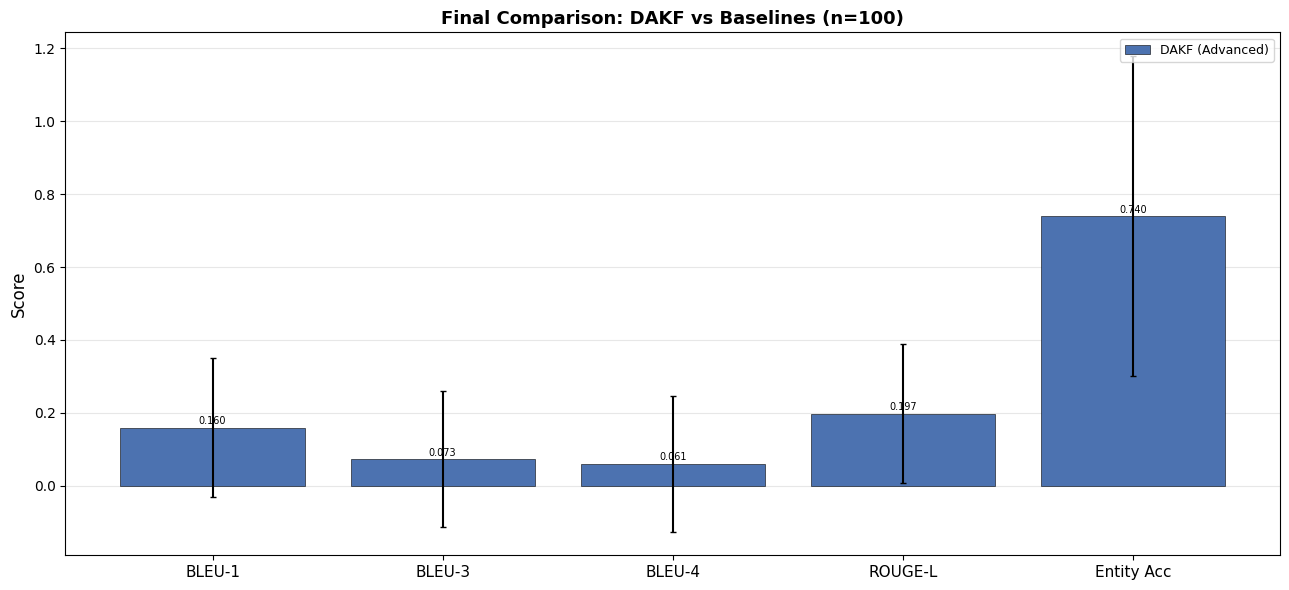

final_comparison.png saved.
final_all_results.json saved.


In [20]:
# ============================================================
# Cell 5: Final comparison, table, and figure
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

existing["DAKF (Advanced)"] = dakf_summary

# ---- Table ----
print("\n" + "=" * 92)
print("Final Table: All Methods on Radiology_mini (n=100)")
print("=" * 92)
print(f"{'Method':<22}{'BLEU-1':<11}{'BLEU-3':<11}{'BLEU-4':<11}"
      f"{'ROUGE-L':<11}{'Entity':<11}")
print("-" * 92)
for name, r in existing.items():
    print(
        f"{name:<22}"
        f"{r['bleu_1']['mean']:<11.4f}"
        f"{r['bleu_3']['mean']:<11.4f}"
        f"{r['bleu_4']['mean']:<11.4f}"
        f"{r['rouge_l']['mean']:<11.4f}"
        f"{r['entity_acc']['mean']:<11.4f}"
    )
print("=" * 92)

# ---- Best per metric ----
metrics = ["bleu_1", "bleu_3", "bleu_4", "rouge_l", "entity_acc"]
print("\nBest method per metric:")
for m in metrics:
    best = max(existing.items(), key=lambda kv: kv[1][m]["mean"])
    print(f"  {m:<12}: {best[0]:<22} ({best[1][m]['mean']:.4f})")

# ---- Figure ----
methods = list(existing.keys())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
metric_labels = ["BLEU-1", "BLEU-3", "BLEU-4", "ROUGE-L", "Entity Acc"]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(metrics))
width = 0.8 / len(methods)
for i, (method, color) in enumerate(zip(methods, colors[:len(methods)])):
    means = [existing[method][k]["mean"] for k in metrics]
    stds = [existing[method][k]["std"] for k in metrics]
    bars = ax.bar(
        x + i * width, means, width, label=method, color=color,
        yerr=stds, capsize=2, edgecolor="black", linewidth=0.4,
    )
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7,
        )
ax.set_xticks(x + width * (len(methods) - 1) / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Final Comparison: DAKF vs Baselines (n=100)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/final_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("final_comparison.png saved.")

# ---- Save combined ----
with open(f"{WORK_DIR}/final_all_results.json", "w") as f:
    json.dump(existing, f, indent=2)
print("final_all_results.json saved.")